In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# Leer el archivo CSV
df = pd.read_csv('ventas.csv')

# Mostrar las primeras filas
print(df.head())


        Fecha    Producto   Categoria  Precio  Cantidad        Ciudad
0  2024-01-01      Camisa        Ropa    25.0         2  Buenos Aires
1  2024-01-02     Zapatos     Calzado    50.0         1       Córdoba
2  2024-01-03    Pantalón        Ropa    30.0         1       Rosario
3  2024-01-04  Zapatillas     Calzado    60.0         3       Mendoza
4  2024-01-05    Sombrero  Accesorios    15.0         2         Salta


In [5]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7 entries, 0 to 6
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Fecha      7 non-null      object 
 1   Producto   7 non-null      object 
 2   Categoria  7 non-null      object 
 3   Precio     7 non-null      float64
 4   Cantidad   7 non-null      int64  
 5   Ciudad     7 non-null      object 
dtypes: float64(1), int64(1), object(4)
memory usage: 468.0+ bytes
None


In [ ]:
#filtro de precios mayores a 30
precio_menor=df.Precio>30
print (df[precio_menor])

        Fecha    Producto Categoria  Precio  Cantidad   Ciudad
1  2024-01-02     Zapatos   Calzado    50.0         1  Córdoba
3  2024-01-04  Zapatillas   Calzado    60.0         3  Mendoza


In [ ]:
#filtro de columnas a la columna ciudad
ventas_ba= df['Ciudad'] =='Buenos Aires'
print(df[ventas_ba])

        Fecha Producto Categoria  Precio  Cantidad        Ciudad
0  2024-01-01   Camisa      Ropa    25.0         2  Buenos Aires
5  2024-01-06   Remera      Ropa    20.0         4  Buenos Aires


In [ ]:
#filtro de ciudad y precio (2 condiciones)
ventas_rosario=(df['Ciudad']=='Rosario') & (df['Precio']<= 30)
print (df[ventas_rosario]) 

        Fecha  Producto Categoria  Precio  Cantidad   Ciudad
2  2024-01-03  Pantalón      Ropa    30.0         1  Rosario


In [ ]:
#filtro condiconal entre ciudad y precio
ventas_salta=(df['Ciudad']=='Salta') | (df['Precio']> 50)
print (df[ventas_salta]) 


       Fecha    Producto   Categoria  Precio  Cantidad   Ciudad  Total  \
3 2024-01-04  Zapatillas     Calzado    60.0         3  Mendoza  180.0   
4 2024-01-05    Sombrero  Accesorios    15.0         2    Salta   30.0   

       Mes  
3  2024-01  
4  2024-01  


In [ ]:
#creacion de nueva columna a partir de otra 2
df['Total']=df['Precio']*df['Cantidad']
print (df) 

        Fecha    Producto   Categoria  Precio  Cantidad        Ciudad  Total
0  2024-01-01      Camisa        Ropa    25.0         2  Buenos Aires   50.0
1  2024-01-02     Zapatos     Calzado    50.0         1       Córdoba   50.0
2  2024-01-03    Pantalón        Ropa    30.0         1       Rosario   30.0
3  2024-01-04  Zapatillas     Calzado    60.0         3       Mendoza  180.0
4  2024-01-05    Sombrero  Accesorios    15.0         2         Salta   30.0
5  2024-01-06      Remera        Ropa    20.0         4  Buenos Aires   80.0
6  2024-01-07      Medias  Accesorios     5.0         6       Córdoba   30.0


In [11]:
# Agrupar por 'Ciudad' y calcular la suma del 'Total'
ventas_por_ciudad = df.groupby('Ciudad')['Total'].max().sort_values(ascending=False)

# Mostrar el resultado
print(ventas_por_ciudad)

Ciudad
Mendoza         180.0
Buenos Aires     80.0
Córdoba          50.0
Rosario          30.0
Salta            30.0
Name: Total, dtype: float64


In [12]:
ventas_ciudad_mayor_a_menor=ventas_por_ciudad.sort_values(ascending=False)
print (ventas_ciudad_mayor_a_menor)

Ciudad
Mendoza         180.0
Buenos Aires     80.0
Córdoba          50.0
Rosario          30.0
Salta            30.0
Name: Total, dtype: float64


In [ ]:
#aplicacion de 3 filtros en la columna tota por ciudad
ventas_agg = df.groupby('Ciudad')['Total'].agg(['sum', 'mean', 'max'])
print (ventas_agg)

                sum   mean    max
Ciudad                           
Buenos Aires  130.0   65.0   80.0
Córdoba        80.0   40.0   50.0
Mendoza       180.0  180.0  180.0
Rosario        30.0   30.0   30.0
Salta          30.0   30.0   30.0


In [ ]:
#creacion de archivo csv
ventas_agg.to_csv("practica a csv")

In [ ]:
#lectura de archivo csv
pd_ventas=pd.read_csv('practica_a_csv')
print(pd_ventas)

         Ciudad    sum   mean    max
0  Buenos Aires  130.0   65.0   80.0
1       Córdoba   80.0   40.0   50.0
2       Mendoza  180.0  180.0  180.0
3       Rosario   30.0   30.0   30.0
4         Salta   30.0   30.0   30.0


In [ ]:
#pivot table con las columnas ciudad y sumatoria de total
pivot_ventas=pd.pivot_table(df,
                     values='Total',
                     index='Ciudad',
                      aggfunc='sum',
                      fill_value=0)

print(pivot_ventas) 
                       

              Total
Ciudad             
Buenos Aires  130.0
Córdoba        80.0
Mendoza       180.0
Rosario        30.0
Salta          30.0


In [17]:
df['Fecha']=pd.to_datetime(df['Fecha'])
df['Mes']=df['Fecha'].dt.to_period('M')
ventas_ciudad_mes=pd.pivot_table(df,values='Total',
                                 index='Ciudad',
                                 columns='Mes')
print(df['Mes'])

0    2024-01
1    2024-01
2    2024-01
3    2024-01
4    2024-01
5    2024-01
6    2024-01
Name: Mes, dtype: period[M]


In [ ]:
#ventas detallada de producto por ciudad, se completan casillas vacias con valor 0
ventas_total_producto=pd.pivot_table(df,values=['Total','Cantidad'],
                                      index='Ciudad',
                                      columns='Producto',
                                      fill_value=0,
                                      aggfunc=
                                      {'Total':'sum','Cantidad':'mean'})
print(ventas_total_producto)

             Cantidad                                                     \
Producto       Camisa Medias Pantalón Remera Sombrero Zapatillas Zapatos   
Ciudad                                                                     
Buenos Aires      2.0    0.0      0.0    4.0      0.0        0.0     0.0   
Córdoba           0.0    6.0      0.0    0.0      0.0        0.0     1.0   
Mendoza           0.0    0.0      0.0    0.0      0.0        3.0     0.0   
Rosario           0.0    0.0      1.0    0.0      0.0        0.0     0.0   
Salta             0.0    0.0      0.0    0.0      2.0        0.0     0.0   

              Total                                                     
Producto     Camisa Medias Pantalón Remera Sombrero Zapatillas Zapatos  
Ciudad                                                                  
Buenos Aires   50.0    0.0      0.0   80.0      0.0        0.0     0.0  
Córdoba         0.0   30.0      0.0    0.0      0.0        0.0    50.0  
Mendoza         0.0    0.0

In [19]:
ventas_por_ciudad = df.groupby('Ciudad')[['Total','Precio']].sum()
print(ventas_por_ciudad)

              Total  Precio
Ciudad                     
Buenos Aires  130.0    45.0
Córdoba        80.0    55.0
Mendoza       180.0    60.0
Rosario        30.0    30.0
Salta          30.0    15.0


In [ ]:
#data frame con un filtro diferente por columna
resumen_ciudad=df.groupby('Ciudad')[['Total','Precio','Cantidad']].agg({'Total':'sum','Precio':'mean','Cantidad':'sum'})
print(resumen_ciudad)

              Total  Precio  Cantidad
Ciudad                               
Buenos Aires  130.0    22.5         6
Córdoba        80.0    27.5         7
Mendoza       180.0    60.0         3
Rosario        30.0    30.0         1
Salta          30.0    15.0         2


In [ ]:
#ordenar dataframe segun total de venta
ordenado = resumen_ciudad.sort_values(by='Total', ascending=False)
print(ordenado)

              Total  Precio  Cantidad
Ciudad                               
Mendoza       180.0    60.0         3
Buenos Aires  130.0    22.5         6
Córdoba        80.0    27.5         7
Rosario        30.0    30.0         1
Salta          30.0    15.0         2


In [ ]:
#creacion de mascara boleana donde se filtra cantidad y precio 
mascara_ventas=(resumen_ciudad['Cantidad']>5) & (resumen_ciudad['Precio']<40)
resultado=resumen_ciudad[mascara_ventas].sort_values(by='Total',ascending=False)
print(resultado)

              Total  Precio  Cantidad
Ciudad                               
Buenos Aires  130.0    22.5         6
Córdoba        80.0    27.5         7


In [23]:
print(resumen_ciudad[['Cantidad','Precio']].describe)

<bound method NDFrame.describe of               Cantidad  Precio
Ciudad                        
Buenos Aires         6    22.5
Córdoba              7    27.5
Mendoza              3    60.0
Rosario              1    30.0
Salta                2    15.0>


In [28]:
resumen_ciudad_producto = df.groupby(['Ciudad', 'Producto']).agg({
    'Cantidad': 'sum',
    'Precio': 'mean',
    'Total': 'sum'
})

# Mostrar el resumen
print(resumen_ciudad_producto)

                         Cantidad  Precio  Total
Ciudad       Producto                           
Buenos Aires Camisa             2    25.0   50.0
             Remera             4    20.0   80.0
Córdoba      Medias             6     5.0   30.0
             Zapatos            1    50.0   50.0
Mendoza      Zapatillas         3    60.0  180.0
Rosario      Pantalón           1    30.0   30.0
Salta        Sombrero           2    15.0   30.0


In [ ]:
#creacion de pivot table donde se usa la misma columna con valores minimo y maximo
resumen_precio = df.groupby('Ciudad').agg({
    'Precio': [lambda x: x.max(), lambda x: x.min()]
})

print(resumen_precio)

                 Precio           
             <lambda_0> <lambda_1>
Ciudad                            
Buenos Aires       25.0       20.0
Córdoba            50.0        5.0
Mendoza            60.0       60.0
Rosario            30.0       30.0
Salta              15.0       15.0


In [26]:
print(resumen_ciudad.columns)

Index(['Total', 'Precio', 'Cantidad'], dtype='object')


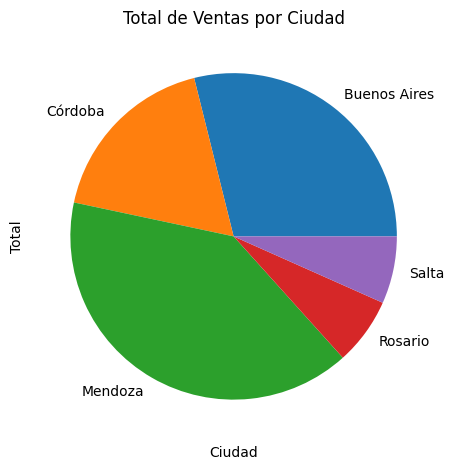

In [27]:
resumen_ciudad['Total'].plot(kind='pie')
plt.title('Total de Ventas por Ciudad')
plt.xlabel('Ciudad')
plt.ylabel('Total')
plt.tight_layout()
plt.show()